# Import Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import scipy as sp
import scipy.io.wavfile as wf
import librosa
import librosa.display
import IPython.display as ipd
import os
import soundfile as sf
import lightgbm
%matplotlib inline
from itertools import cycle
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# Preparing the CSV

In [35]:
train_df = pd.read_csv('development.csv')
train_df['path'] = 'D:/Data Science and Engineering/Datasets/' + train_df['path']
audiopath = train_df['path'].tolist()

audiopath[:5]

['D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/0a3129c0-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/0ee42a80-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/1d9f3920-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/269fc210-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/5bbda3f0-4478-11e9-a9a5-5dbec3b8816a.wav']

In [36]:
train_df.isnull().sum()

Id                                       0
path                                     0
speakerId                                0
action                                   0
object                                   0
Self-reported fluency level              0
First Language spoken                    0
Current language used for work/school    0
gender                                   0
ageRange                                 0
dtype: int64

In [37]:
train_df[train_df.eq('none')].count()

Id                                          0
path                                        0
speakerId                                   0
action                                      0
object                                   1113
Self-reported fluency level                 0
First Language spoken                       0
Current language used for work/school       0
gender                                      0
ageRange                                    0
dtype: int64

In [38]:
train_df[train_df['object'] == 'none']['action']

0       change language
47      change language
48      change language
49      change language
50      change language
             ...       
9815    change language
9816    change language
9817    change language
9845    change language
9847    change language
Name: action, Length: 1113, dtype: object

In [39]:
train_df.duplicated().sum()

0

In [40]:
train_df['intention'] = train_df.pop('action') + train_df.pop('object')

train_df

,Id,path,speakerId,Self-reported fluency level,First Language spoken,Current language used for work/school,gender,ageRange,intention
0,0,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,change languagenone
1,1,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,activatemusic
2,2,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,deactivatelights
3,3,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,increasevolume
4,4,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,increasevolume
...,...,...,...,...,...,...,...,...,...
9849,9849,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,native,English (United States),English (United States),male,22-40,decreasevolume
9850,9850,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,native,English (United States),English (United States),male,22-40,deactivatelights
9851,9851,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,native,English (United States),English (United States),male,22-40,deactivatelights
9852,9852,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,native,English (United States),English (United States),male,22-40,deactivatelights


In [41]:
train_df['intention'].value_counts()

intention
increasevolume         2614
decreasevolume         2386
increaseheat           1209
decreaseheat           1189
change languagenone    1113
activatemusic           791
deactivatelights        552
Name: count, dtype: int64

In [42]:
train_df['speakerId'].nunique()

87

In [43]:
train_df.drop(['Id' , 'speakerId'], axis=1, inplace=True)

In [44]:
train_df['Self-reported fluency level '].value_counts() / len(train_df)

Self-reported fluency level 
native          0.958393
advanced        0.035113
basic           0.005683
intermediate    0.000812
Name: count, dtype: float64

In [45]:
train_df['First Language spoken'].value_counts() / len(train_df)

First Language spoken
English (United States)    0.978486
French (Canada)            0.015019
Spanish (Venezuela)        0.003552
Telugu                     0.002131
English (Canada)           0.000812
Name: count, dtype: float64

In [46]:
train_df['Current language used for work/school'].value_counts() / len(train_df)

Current language used for work/school
English (United States)    0.974021
English (Canada)           0.015831
English (Australia)        0.006596
Spanish (Venezuela)        0.003552
Name: count, dtype: float64

In [47]:
train_df.drop(['Self-reported fluency level ', 'First Language spoken', 'Current language used for work/school'], axis=1, inplace=True)

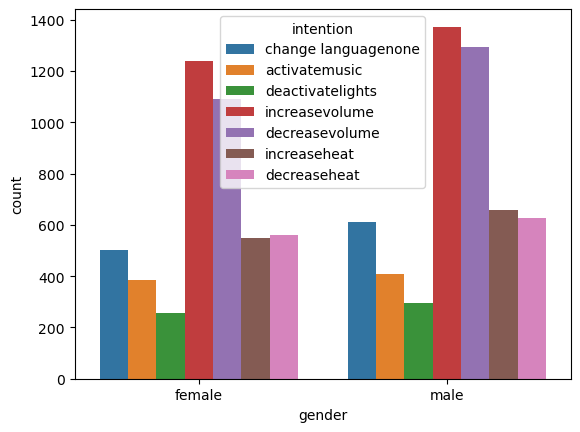

In [51]:
train_df['intention'] = train_df['intention'].str.strip()

sns.countplot(data=train_df, x='gender', hue='intention')
plt.show()

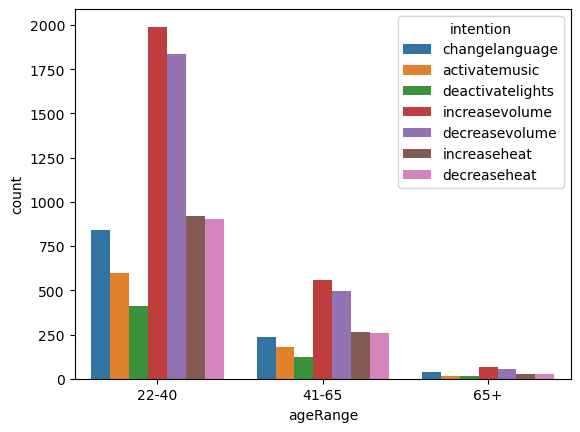

In [54]:
sns.countplot(data=train_df, x='ageRange', hue='intention')
plt.show()

In [55]:
train_df.drop(['gender', 'ageRange'], axis=1, inplace=True)

In [56]:
train_df

,path,intention
0,D:/Data Science and Engineering/Datasets/dsl_d...,changelanguage
1,D:/Data Science and Engineering/Datasets/dsl_d...,activatemusic
2,D:/Data Science and Engineering/Datasets/dsl_d...,deactivatelights
3,D:/Data Science and Engineering/Datasets/dsl_d...,increasevolume
4,D:/Data Science and Engineering/Datasets/dsl_d...,increasevolume
...,...,...
9849,D:/Data Science and Engineering/Datasets/dsl_d...,decreasevolume
9850,D:/Data Science and Engineering/Datasets/dsl_d...,deactivatelights
9851,D:/Data Science and Engineering/Datasets/dsl_d...,deactivatelights
9852,D:/Data Science and Engineering/Datasets/dsl_d...,deactivatelights


### Extract MFFCs


In [21]:
DBT = []
mfccs = []
target_length = 231525  # 10.5 seconds in samples (assuming 22050 Hz sample rate)
top_db = 20  # dB threshold for trimming

for path in tqdm(audiopath, desc="Processing Audio"):
    # Load audio (retain original sample rate)
    x, sr = librosa.load(path, sr=None)

    # Get duration (avoid redundant file reading)
    duration_before_trim = len(x) / sr

    # Trim silence
    trimmed_audio, _ = librosa.effects.trim(x, top_db=top_db)

    # Pad or truncate to the target length
    processed_audio = librosa.util.fix_length(trimmed_audio, size=target_length)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=processed_audio, sr=sr)

    # Store results
    DBT.append(duration_before_trim)
    mfccs.append(mfcc)

Processing Audio: 100%|██████████| 9854/9854 [02:51<00:00, 57.31it/s]


In [11]:
DBT2 = []
mfccs2 = []
target_length = 231525  # 10.5 seconds in samples (assuming 22050 Hz sample rate)
top_db = 20  # dB threshold for trimming

for path in tqdm(audiopath_new, desc="Processing Audio"):
    # Load audio (retain original sample rate)
    x, sr = librosa.load(path, sr=None)

    # Get duration (avoid redundant file reading)
    duration_before_trim = len(x) / sr

    # Trim silence
    trimmed_audio, _ = librosa.effects.trim(x, top_db=top_db)

    # Pad or truncate to the target length
    processed_audio = librosa.util.fix_length(trimmed_audio, size=target_length)

    # Extract MFCCs
    mfcc2 = librosa.feature.mfcc(y=processed_audio, sr=sr)

    # Store results
    DBT2.append(duration_before_trim)
    mfccs2.append(mfcc2)

Processing Audio: 100%|██████████| 9854/9854 [04:18<00:00, 38.08it/s]


### Visualizations

c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


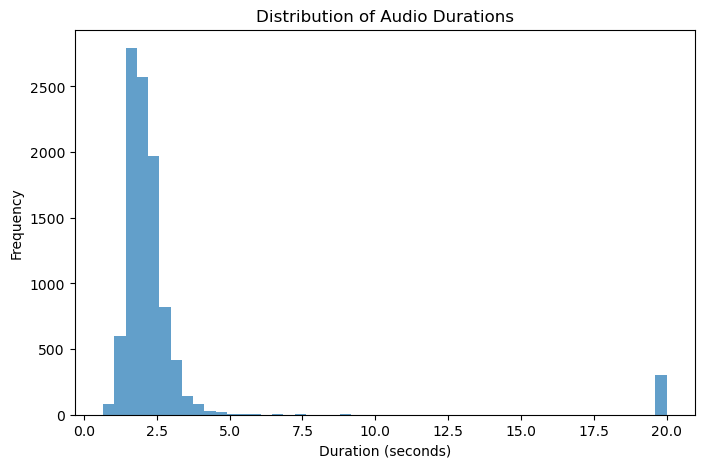

Upper duration bound: 3.48 seconds
Trimmed and saved 9854 files to:
D:\Data Science and Engineering\Datasets\dsl_data\trimmed audio


In [ ]:
output_dir = r"D:\Data Science and Engineering\Datasets\dsl_data\trimmed audio"
os.makedirs(output_dir, exist_ok=True)

def get_audio_duration(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)
        return librosa.get_duration(y=y, sr=sr)
    except Exception as e:
        print(f"Failed on {file_path}: {e}")
        return None

train_df["duration"] = train_df["path"].apply(get_audio_duration)

train_df = train_df[train_df["duration"].notnull()]

plt.figure(figsize=(8, 5))
plt.hist(train_df["duration"], bins=50, color="tab:blue", alpha=0.7)
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of Audio Durations")
plt.show()

Q1 = train_df["duration"].quantile(0.25)
Q3 = train_df["duration"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print(f"Upper duration bound: {upper_bound:.2f} seconds")

def trim_and_save_audio(file_path, max_duration, output_dir):
    try:
        y, sr = librosa.load(file_path, sr=None)
        duration = librosa.get_duration(y=y, sr=sr)
        if duration > max_duration:
            y = y[:int(sr * max_duration)]
        
        filename = os.path.basename(file_path)
        new_path = os.path.join(output_dir, filename)
        sf.write(new_path, y, sr)
        return new_path, librosa.get_duration(y=y, sr=sr)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None

new_paths = []
new_durations = []

for path in train_df["path"]:
    new_path, new_duration = trim_and_save_audio(path, upper_bound, output_dir)
    new_paths.append(new_path)
    new_durations.append(new_duration)

train_df["new_path"] = new_paths
train_df["new_duration"] = new_durations

train_df = train_df[train_df["new_path"].notnull()]

print(f"Trimmed and saved {len(train_df)} files to:\n{output_dir}")

In [10]:
audiopath_new = train_df['new_path'].tolist()

audiopath_new[:5]

['D:\\Data Science and Engineering\\Datasets\\dsl_data\\trimmed audio\\0a3129c0-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:\\Data Science and Engineering\\Datasets\\dsl_data\\trimmed audio\\0ee42a80-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:\\Data Science and Engineering\\Datasets\\dsl_data\\trimmed audio\\1d9f3920-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:\\Data Science and Engineering\\Datasets\\dsl_data\\trimmed audio\\269fc210-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:\\Data Science and Engineering\\Datasets\\dsl_data\\trimmed audio\\5bbda3f0-4478-11e9-a9a5-5dbec3b8816a.wav']

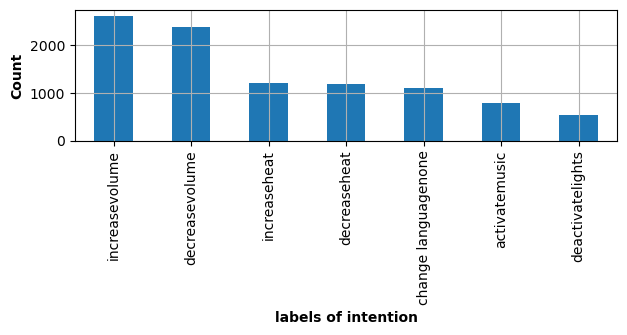

In [59]:
ax = train_df['intention'].value_counts().plot(kind='bar', colormap = 'tab10', figsize=(7,1.7))
plt.xlabel("labels of intention",fontweight = 'bold')
plt.ylabel("Count",fontweight = 'bold')
plt.grid()
plt.show()

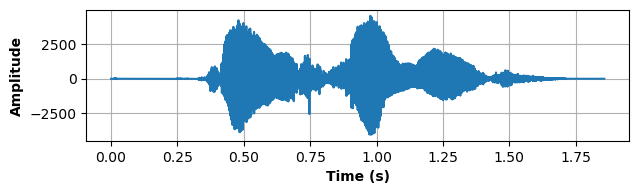

In [52]:
wavfile= audiopath[0]
a, b= wf.read(wavfile)

duration= len(b)/a 
c= np.linspace(0,duration,len(b))
plt.figure(figsize=(7,1.7))
plt.plot(c,b)
plt.grid()
plt.xlabel('Time (s)', fontweight = 'bold')
plt.ylabel('Amplitude', fontweight = 'bold')
plt.show()

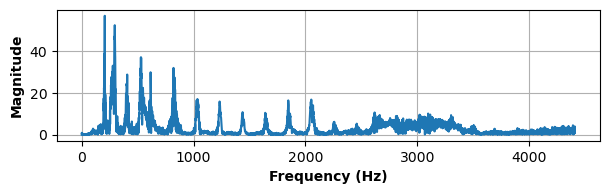

In [53]:
k,sr= librosa.load(audiopath[0])

a = np.fft.fft(k)
a_mag = np.absolute(a)
plt.figure(figsize=(7,1.7))
b = np.linspace(0, sr, len(a_mag))
b_bins = int(len(a_mag)*0.2)  
plt.plot(b[:b_bins], a_mag[:b_bins])
plt.ylabel('Magnitude', fontweight = 'bold')
plt.xlabel('Frequency (Hz)', fontweight = 'bold')
plt.grid()
plt.show()

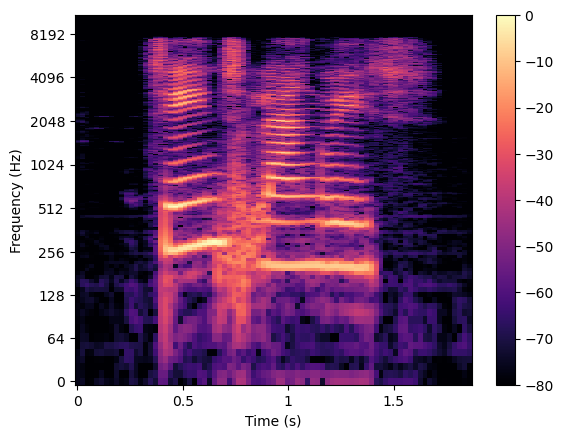

<Figure size 500x400 with 0 Axes>

In [54]:
k, sr= librosa.load(audiopath[0])
a= librosa.stft(k)
b= librosa.amplitude_to_db(np.abs(a), ref=np.max)

fig, ax= plt.subplots()
pic= librosa.display.specshow(b, x_axis='time', y_axis='log', ax=ax)
ax.set(ylabel='Frequency (Hz)', xlabel='Time (s)')
fig.colorbar(pic, ax=ax)
plt.figure(figsize=(5,4))
plt.show()

# Train Data

In [22]:
feature= np.array(mfccs)
feature= feature.reshape(feature.shape[0], -1)

In [23]:
x= feature
y= train_df['intention']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=4, stratify=y)

In [ ]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

In [ ]:
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [26]:
smote = SMOTE(random_state=4, sampling_strategy='not majority')

x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train_encoded)

In [ ]:
pca = PCA(n_components=500)
x_train_pca = pca.fit_transform(x_train_balanced)
x_test_pca = pca.transform(x_test_scaled)

# Classification Models

In [20]:
svc = SVC(kernel='rbf', C=40, gamma='scale')
svc.fit(x_train_pca, y_train_balanced)

y_pred = svc.predict(x_test_pca)
accuracy_score(y_test_encoded, y_pred) * 100

69.50786402841197

In [27]:
LGBM= lightgbm.LGBMClassifier(random_state=4, n_estimators=2000, num_leaves=70, learning_rate=0.05)
LGBM.fit(x_train_balanced, y_train_balanced)

#preds_train = LGBM.predict(x_train)
y_pred = LGBM.predict(x_test)
accuracy_score(y_test_encoded, y_pred) * 100

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.343522 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 465718
[LightGBM] [Info] Number of data points in the train set: 14637, number of used features: 2481
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

72.55200405885337